In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### DataSet Overview

- Understanding the structure, number of columns, and data types.

In [102]:
original_data = pd.read_csv("hotel_bookings.csv")
original_data.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Handling Missing Values

- Several columns contain missing values which need to be treated before analysis.

In [8]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [9]:
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna("Unknown")
df['agent'] = df['agent'].fillna(0)

# drop company column because it has too many missing values
df = df.drop(columns=['company'])

### Removing Duplicate Rows

- Duplicate booking records can distort analysis and must be removed.

In [11]:
df.duplicated().sum()

np.int64(32001)

In [12]:
df = df.drop_duplicates()

### Treating Outliers in Average Daily Rate (ADR)

- Extreme ADR values can distort analysis and need to be removed.

In [14]:
df['adr'].describe()

count    87389.000000
mean       106.339070
std         55.013097
min         -6.380000
25%         72.000000
50%         98.100000
75%        134.000000
max       5400.000000
Name: adr, dtype: float64

In [15]:
df = df[df['adr'] < 500]

### Feature Engineering

- New features are created to improve analytical insights.

In [17]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [18]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [19]:
df['total_revenue'] = df['adr'] * df['total_stay']

In [20]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

#### Data Check

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87386 entries, 0 to 119389
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87386 non-null  object        
 1   is_canceled                     87386 non-null  int64         
 2   lead_time                       87386 non-null  int64         
 3   arrival_date_year               87386 non-null  int64         
 4   arrival_date_month              87386 non-null  object        
 5   arrival_date_week_number        87386 non-null  int64         
 6   arrival_date_day_of_month       87386 non-null  int64         
 7   stays_in_weekend_nights         87386 non-null  int64         
 8   stays_in_week_nights            87386 non-null  int64         
 9   adults                          87386 non-null  int64         
 10  children                        87386 non-null  float64       
 11  babies

In [23]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay,total_guests,total_revenue
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2.0,196.0


In [24]:
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

In [25]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

In [26]:
month_order = [
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]

df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)

In [27]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_stay',
       'total_guests', 'total_revenue'],
      dtype='object')

In [28]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay,total_guests,total_revenue
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2.0,196.0


In [29]:
df.shape

(87220, 34)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87220 entries, 0 to 119389
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87220 non-null  object        
 1   is_canceled                     87220 non-null  int64         
 2   lead_time                       87220 non-null  int64         
 3   arrival_date_year               87220 non-null  int64         
 4   arrival_date_month              87220 non-null  category      
 5   arrival_date_week_number        87220 non-null  int64         
 6   arrival_date_day_of_month       87220 non-null  int64         
 7   stays_in_weekend_nights         87220 non-null  int64         
 8   stays_in_week_nights            87220 non-null  int64         
 9   adults                          87220 non-null  int64         
 10  children                        87220 non-null  float64       
 11  babies

In [31]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,total_stay,total_guests,total_revenue
count,87220.000000,87220.000000,87220.000000,87220.000000,87220.000000,87220.000000,87220.000000,87220.000000,87220.000000,87220.000000,...,87220.000000,87220.000000,87220.000000,87220.000000,87220.000000,87220.000000,87220,87220.000000,87220.000000,87220.000000
mean,0.275258,79.979202,2016.210376,26.834740,15.815971,1.004701,2.624134,1.879420,0.138913,0.010846,...,0.268516,81.093637,0.746377,106.449952,0.084304,0.698980,2016-08-31 03:01:35.592753920,3.628835,2.029179,394.916168
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00,0.000000,1.000000,-63.800000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,9.000000,0.000000,72.250000,0.000000,0.000000,2016-03-18 00:00:00,2.000000,2.000000,153.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,9.000000,0.000000,98.190000,0.000000,0.000000,2016-09-08 00:00:00,3.000000,2.000000,299.200000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,...,0.000000,240.000000,0.000000,134.100000,0.000000,1.000000,2017-03-05 00:00:00,5.000000,2.000000,504.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,18.000000,535.000000,391.000000,451.500000,8.000000,5.000000,2017-09-14 00:00:00,69.000000,55.000000,7590.000000
std,0.446647,86.060132,0.686049,13.669122,8.835710,1.027422,2.039849,0.621716,0.456289,0.113710,...,0.710664,109.979423,10.001571,51.846541,0.281656,0.832059,NaN,2.742961,0.790140,369.068453


## Data Cleaning Summary

- Filled missing values in children, country, and agent
- Dropped company column due to excessive missing values
- Removed duplicate booking records
- Treated extreme ADR outliers
- Created new features : total_stay, total_guests, total_revenue
- Converted reservation_status_date to datetime format

##### Final dataset size : 87220 rows and 34 columns

## Exploratory Data Analysis(EDA)

In this section we analyze booking patterns, customer behavior, and cancellation trends using visualization techniques

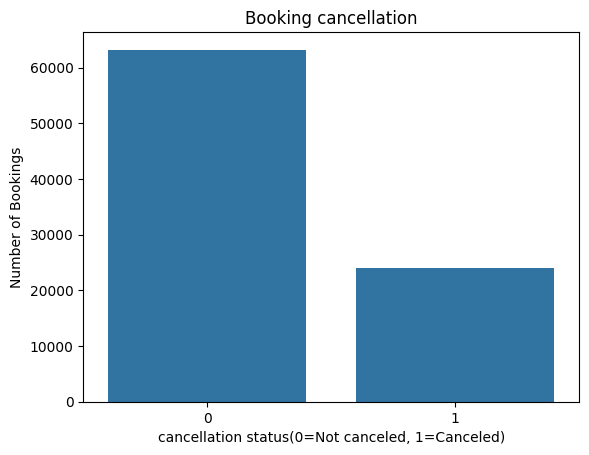

is_canceled
0    72.474203
1    27.525797
Name: proportion, dtype: float64

In [40]:
sns.countplot(x="is_canceled",data=df)
plt.xlabel("cancellation status(0=Not canceled, 1=Canceled)")
plt.ylabel("Number of Bookings")
plt.title("Booking cancellation")
plt.show()
df['is_canceled'].value_counts(normalize=True)*100

### Insight

About 27% of bookings are getting canceled. This is quite high and can affect hotel revenue. 
From this, we can further analyze different factors to understand customer behavior and 
find the reasons behind cancellations.

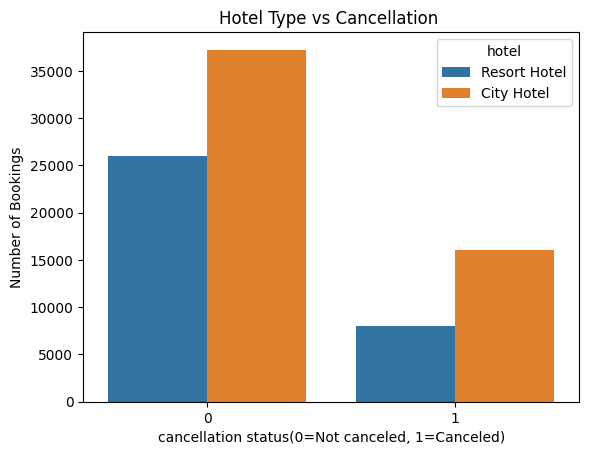

In [49]:
sns.countplot(x="is_canceled",data=df,hue="hotel")
plt.xlabel("cancellation status(0=Not canceled, 1=Canceled)")
plt.ylabel("Number of Bookings")
plt.title("Hotel Type vs Cancellation ")
plt.show()

### Insight

City hotels have higher bookings as well as cancellations compared to resort hotels, indicating a higher cancellation risk. Further analysis is needed to understand the reasons behind these cancellations.

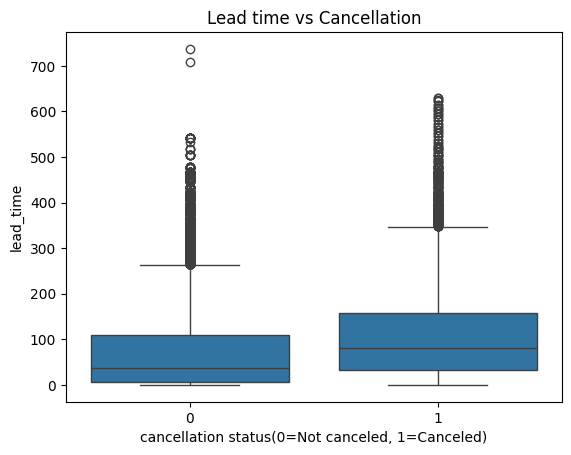

In [48]:
sns.boxplot(x="is_canceled",y="lead_time",data=df)
plt.xlabel("cancellation status(0=Not canceled, 1=Canceled)")
plt.title("Lead time vs Cancellation")
plt.show()

### Insight

Bookings with higher lead time are more likely to be canceled. This indicates that customers who book well in advance tend to cancel more frequently.

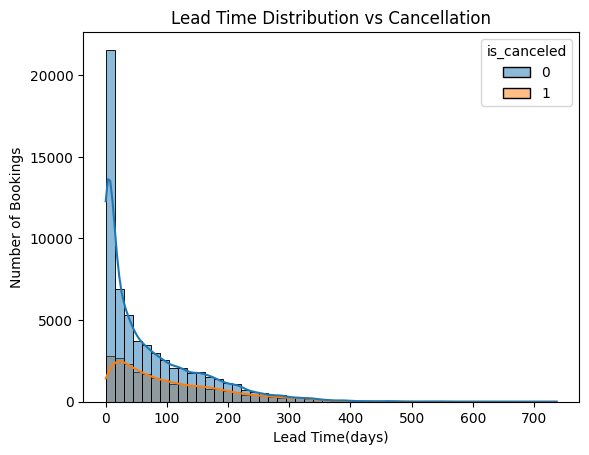

In [94]:
sns.histplot(x="lead_time",hue="is_canceled",data=df,bins=50,kde=True)
plt.xlabel("Lead Time(days)")
plt.ylabel("Number of Bookings")
plt.title("Lead Time Distribution vs Cancellation")
plt.show()

### Insights

Most bookings are made with shorter lead times, but cancellations are more common among bookings with longer lead times. This suggests that customers who book well in advance are more likely to cancel, whereas last-minute bookings are more stable.

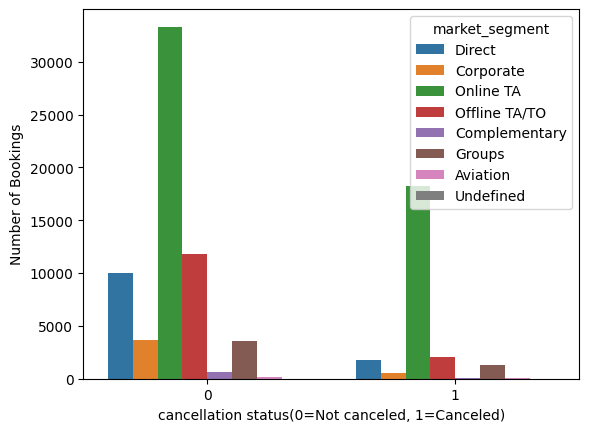

In [ ]:
sns.countplot(x="is_canceled",data=df,hue="market_segment")
plt.xlabel("cancellation status(0=Not canceled, 1=Canceled)")
plt.ylabel("Number of Bookings")
plt.title("Market Segment vs Cancellation")
plt.show()

### Insight

Online travel agents (Online TA) contribute the highest number of bookings as well as cancellations, indicating a higher cancellation risk. In contrast, direct and corporate bookings show relatively lower cancellations, suggesting more reliable customer behavior.

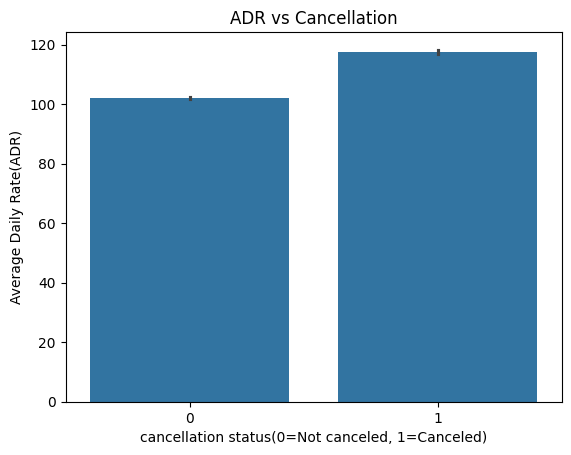

In [82]:
sns.barplot(x="is_canceled",y="adr",data=df)
plt.xlabel("cancellation status(0=Not canceled, 1=Canceled)")
plt.ylabel("Average Daily Rate(ADR)")
plt.title("ADR vs Cancellation")
plt.show()

### Insight

Bookings with higher Average Daily Rate (ADR) tend to have a higher cancellation rate compared to lower-priced bookings. This suggests that customers paying higher prices are more likely to cancel, possibly due to price sensitivity or availability of better alternatives.

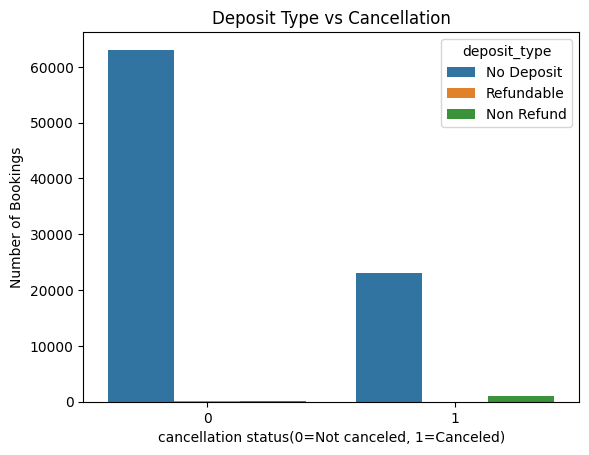

In [60]:
sns.countplot(x="is_canceled",data=df,hue="deposit_type")
plt.xlabel("cancellation status(0=Not canceled, 1=Canceled)")
plt.ylabel("Number of Bookings")
plt.title("Deposit Type vs Cancellation")
plt.show()

### Insight

Bookings with no deposit have the highest number of cancellations, while non-refundable bookings show very low cancellation rates. This indicates that requiring a deposit can reduce the likelihood of cancellations.

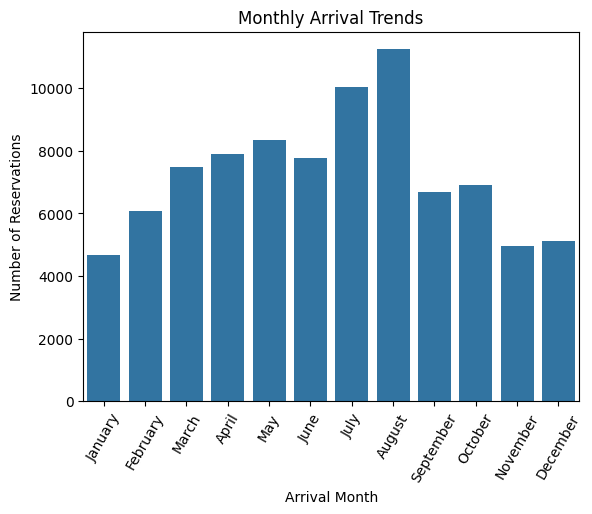

In [70]:
sns.countplot(x="arrival_date_month",data=df)
plt.xticks(rotation=60)
plt.xlabel("Arrival Month")
plt.ylabel("Number of Reservations")
plt.title("Monthly Arrival Trends")
plt.show()

### Insight

Bookings peak during July and August, indicating a strong seasonal demand. In contrast, bookings drop from November to January, showing a clear off-season trend.

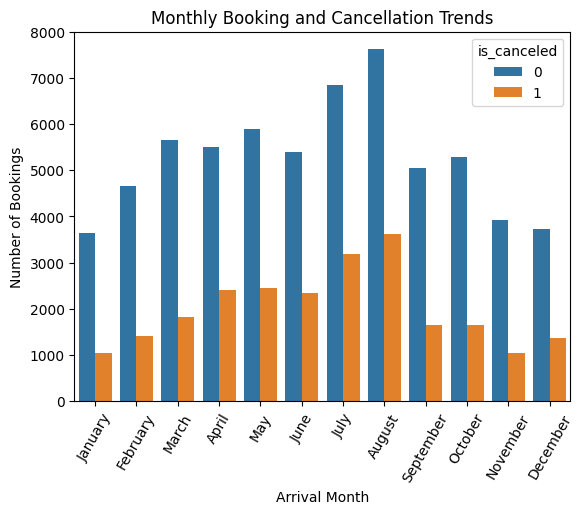

In [81]:
sns.countplot(x="arrival_date_month",data=df,hue="is_canceled")
plt.xticks(rotation=60)
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.title("Monthly Booking and Cancellation Trends")
plt.show()

### Insight

Bookings and cancellations both peak during July and August, indicating high demand during these months. This also suggests that higher booking volume leads to increased cancellations. In contrast, both bookings and cancellations are lower during November to January, showing an off-season trend.

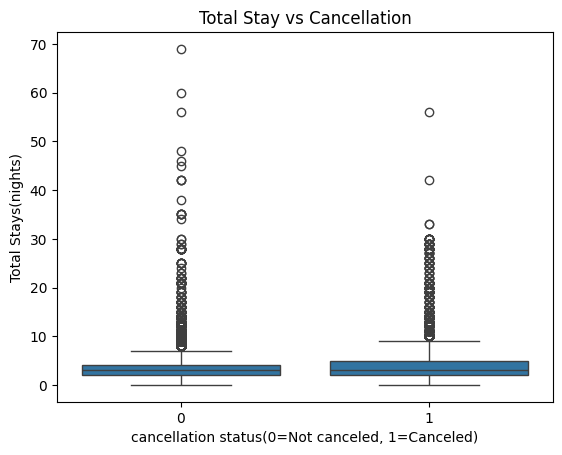

In [99]:
sns.boxplot(x="is_canceled",y="total_stay",data=df)
plt.xlabel("cancellation status(0=Not canceled, 1=Canceled)")
plt.ylabel("Total Stays(nights)")
plt.title("Total Stay vs Cancellation")
plt.show()

### Insight

Most bookings are for short stays of 1–5 nights. However, a few bookings have very long stay durations, and some of these are also canceled. Overall, longer stays show slightly higher cancellation tendencies, but the impact is not very strong.

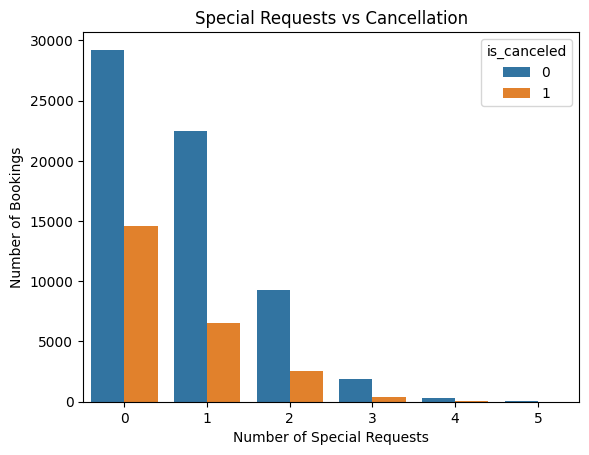

In [101]:
sns.countplot(x="total_of_special_requests",data=df,hue="is_canceled")
plt.xlabel("Number of Special Requests")
plt.ylabel("Number of Bookings")
plt.title("Special Requests vs Cancellation")
plt.show()

### Insight

Customers with no special requests have the highest cancellation rates, while those with more special requests are less likely to cancel. This indicates that customers who are more engaged and specific about their needs tend to complete their bookings.

# Final Summary

- Around 27% of bookings are canceled, indicating a significant business concern.
- City hotels experience higher bookings as well as higher cancellations.
- Longer lead times are strongly associated with higher cancellation chances.
- Higher room prices (ADR) show slightly increased cancellation behavior.
- Customers with no deposit are more likely to cancel.
- Peak demand occurs in July and August, showing clear seasonality.
- Customers with more special requests are less likely to cancel, indicating stronger booking intent.